In [ ]:
import mysql.connector
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set working directory to project root regardless of where notebook is run from
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.dirname(notebook_dir)
os.chdir(project_root)
print(os.getcwd())

/Users/douglas/Documents/GitHub/claims_readmission_analysis


In [2]:
# connect notebook to sql database

load_dotenv()

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password=os.getenv('MYSQL_PASSWORD'),
    database='claims_practice'
)

print("Connection successful" if conn.is_connected() else "Connection failed")

Connection successful


## Benchmark Reference

2010 national benchmark rates for comparison:

| Condition | National Benchmark Rate |
|-----------|------------------------|
| Heart Failure | 24.8% |
| COPD | 20.8% |
| Pneumonia | 16.4% |
| AMI | 15.6% |

**Source:** Rachoin, J.-S., Hunter, K., Varallo, J., & Cerceo, E. (2024). Impact of time from discharge to readmission on outcomes: an observational study from the US National Readmission Database. *BMJ Open, 14*(8), e085466. https://doi.org/10.1136/bmjopen-2024-085466

> Note: These are national rates from 2010, the start of the DE-SynPUF observation period. Observed rates in this analysis come from synthetic data — direct comparison should be interpreted cautiously.

In [ ]:
# Verify df read properly with head()

with open('queries/11_hrrp_condition_readmission_rates.sql', 'r') as f:
    query = f.read()


df = pd.read_sql(query, conn)
print(df.head())

/var/folders/4_/dbg0kzhn7354xv35_by_4slr0000gn/T/ipykernel_71382/4020729497.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  mapped_HRRP_diagnosis  readmission_rate  readmission_count  total_admissions
0         Heart Failure              10.5              330.0              3132
1             Pneumonia              10.3              251.0              2442
2                   AMI               9.9              161.0              1633
3                  COPD               9.8              198.0              2021


In [4]:
# create a benchmark dictionary of the four conditions with cited readmission rate averages

benchmark_rates = {'Heart Failure':24.8,'Pneumonia': 16.4, 'COPD':20.8,'AMI':15.6 }

print(f'benchmark rates dictionary: {benchmark_rates}')

benchmark rates dictionary: {'Heart Failure': 24.8, 'Pneumonia': 16.4, 'COPD': 20.8, 'AMI': 15.6}


In [9]:
# Add 95% confidence intervals to each condition's readmission rate using the
# Wilson score method — same approach as the DRG-level analysis
# (readmission_analysis.ipynb), so the two are directly comparable.
#
# NOTE ON UNITS: unlike 06_readmission_by_drg.sql (which outputs readmission_rate
# as a raw proportion, e.g. 0.228), 11_hrrp_condition_readmission_rates.sql
# outputs readmission_rate already multiplied by 100 (e.g. 10.5). proportion_confint
# always returns bounds on the 0-1 scale, so they're rescaled by *100 here to match
# readmission_rate and benchmark_rates — without this, the error bars and the
# overlap check below would be wrong by a factor of 100.

from statsmodels.stats.proportion import proportion_confint

ci_lower, ci_upper = proportion_confint(
    count=df['readmission_count'],
    nobs=df['total_admissions'],
    alpha=0.05,
    method='wilson'
)
df['ci_lower'] = ci_lower * 100
df['ci_upper'] = ci_upper * 100
df['benchmark'] = df['mapped_HRRP_diagnosis'].map(benchmark_rates)
df['overlaps_benchmark'] = df['ci_upper'] >= df['benchmark']

df[['mapped_HRRP_diagnosis', 'readmission_rate', 'readmission_count',
    'total_admissions', 'ci_lower', 'ci_upper', 'benchmark', 'overlaps_benchmark']]

,mapped_HRRP_diagnosis,readmission_rate,readmission_count,total_admissions,ci_lower,ci_upper,benchmark,overlaps_benchmark
0,Heart Failure,10.5,330.0,3132,9.509071,11.660413,24.8,False
1,Pneumonia,10.3,251.0,2442,9.135731,11.545964,16.4,False
2,AMI,9.9,161.0,1633,8.506097,11.400623,15.6,False
3,COPD,9.8,198.0,2021,8.576329,11.170474,20.8,False


## Statistical Significance of the Gap

None of the 4 HRRP conditions' 95% CIs overlap their national benchmark —
even the upper CI bound stays well below the benchmark in every case (e.g.
Heart Failure's upper bound of ~11.7% vs. a 24.8% benchmark). This is a
stronger claim than the point-estimate-only version: the gap between
observed and benchmark rates here is unlikely to be explained by sampling
variability alone, given the sample sizes involved. (Note: CI non-overlap is
a conservative, informal proxy for a significant difference — not a formal
two-sample test — but the margins here are large enough that this
distinction doesn't change the conclusion.)

## Precision Gain from Condition-Level Grouping

DRG-level readmission rates (readmission_analysis.ipynb) are computed on much
smaller per-group n — the top 5 DRGs by rate (813, 665, 513, 815, 037) have
n = 57–80 admissions each, and their 95% Wilson CIs are correspondingly wide:
roughly 17–21 percentage points from lower to upper bound. All 5 of those
CIs overlap the 14.67% all-cause national benchmark, meaning none of those
DRG-level rates are statistically distinguishable from the benchmark at
that sample size.

The 4 HRRP conditions here have far more admissions per group (1,633–3,132),
and their Wilson CIs are correspondingly tight — about 2.2–2.9 percentage
points wide, roughly 6–10x narrower than the DRG-level CIs above despite
using the same underlying claims data. This is the direct effect of choosing
a coarser (but clinically coherent) unit of analysis: more admissions per
group means more statistical power to detect a real difference from
benchmark, not just a smaller, noisier slice of the same data.

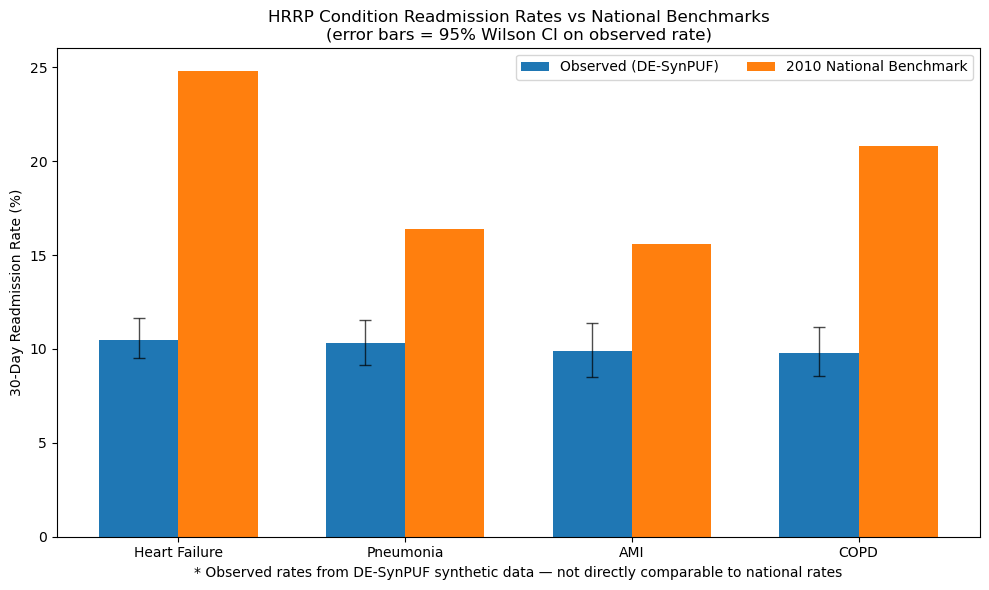

In [6]:
# create a grouped bar chart with Wilson's confidence interval

conditions = df['mapped_HRRP_diagnosis'].tolist()
observed = df['readmission_rate'].tolist()
benchmarks = [benchmark_rates[c] for c in conditions]
lower_err = df['readmission_rate'] - df['ci_lower']
upper_err = df['ci_upper'] - df['readmission_rate']
x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, observed, width, label='Observed (DE-SynPUF)',
               yerr=[lower_err, upper_err], capsize=4,
               error_kw={'ecolor': 'black', 'elinewidth': 1, 'alpha': 0.7})
bars2 = ax.bar(x + width/2, benchmarks, width, label='2010 National Benchmark')

ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('HRRP Condition Readmission Rates vs National Benchmarks\n(error bars = 95% Wilson CI on observed rate)')
ax.set_xlabel('* Observed rates from DE-SynPUF synthetic data — not directly comparable to national rates')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend(loc='upper right', ncols=2)
plt.tight_layout()
plt.savefig('images/hrrp_condition_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()